<a href="https://colab.research.google.com/github/jagadeesh-usd/composer-classification/blob/jag-dev/notebooks/02_Model_Training_and_Evaluation_stride10_seq100_4comp_rerun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Purpose: Load preprocessed data, train models, and evaluate performance.


In [2]:
# 1. Imports
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Conv1D, MaxPooling1D,
                                     Flatten, Input, Concatenate, BatchNormalization,
                                     Embedding, GlobalMaxPooling1D, GlobalAveragePooling1D, SpatialDropout1D)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from tensorflow.keras import regularizers
from tensorflow.keras.losses import CategoricalCrossentropy

In [3]:
# 2. Configuration
SAVE_DIR = "/content/drive/My Drive/composer_project/processed_data_augmented_with_stride10_100"
BATCH_SIZE = 512
EPOCHS = 100

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# # 3. Load Preprocessed Data
# print("Loading preprocessed data...")

# with open(os.path.join(SAVE_DIR, 'train_data.pkl'), 'rb') as f:
#     train_data = pickle.load(f)
# with open(os.path.join(SAVE_DIR, 'val_data.pkl'), 'rb') as f:
#     val_data = pickle.load(f)
# with open(os.path.join(SAVE_DIR, 'test_data.pkl'), 'rb') as f:
#     test_data = pickle.load(f)
# with open(os.path.join(SAVE_DIR, 'preprocessing_data.pkl'), 'rb') as f:
#     preprocessing_data = pickle.load(f)

# # From preprocessing
# note_to_int = preprocessing_data['note_to_int']
# vocab_size  = preprocessing_data['vocab_size']
# composers   = preprocessing_data['composers']
# SEQ_LEN     = preprocessing_data['sequence_length']
# UNK_IDX     = note_to_int['UNK']  # map unknown tokens to this

# label_encoder = LabelEncoder().fit(train_data['labels'])  # fit on TRAIN labels only
# tempo_scaler = StandardScaler()

# # Helper to encode sequences using the TRAIN-built vocab
# def encode_seq(seq):
#     return [note_to_int.get(n, UNK_IDX) for n in seq]

# print(f"Loaded — train:{len(train_data['sequences'])}, val:{len(val_data['sequences'])}, test:{len(test_data['sequences'])}")
# print(f"Vocab size: {vocab_size} | SEQ_LEN: {SEQ_LEN} | Classes: {list(label_encoder.classes_)}")


In [5]:
# 3. Load Preprocessed Data
print("Loading preprocessed data...")

with open(os.path.join(SAVE_DIR, 'train_data.pkl'), 'rb') as f:
    train_data = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'val_data.pkl'), 'rb') as f:
    val_data = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'test_data.pkl'), 'rb') as f:
    test_data = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'preprocessing_data.pkl'), 'rb') as f:
    preprocessing_data = pickle.load(f)

# ========== FILTER FOR SPECIFIC COMPOSERS ==========
# Option 1: Train on 3 composers (exclude Beethoven)
# SELECTED_COMPOSERS = ['Bach', 'Chopin', 'Mozart']  # Change this to select composers

# Option 2: Train on all 4
SELECTED_COMPOSERS = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

def filter_by_composers(data_dict, composers_to_keep):
    """Filter sequences to only include selected composers"""
    filtered_sequences = []
    filtered_labels = []
    filtered_tempos = []

    for seq, label, tempo in zip(data_dict['sequences'],
                                  data_dict['labels'],
                                  data_dict['tempos']):
        if label in composers_to_keep:
            filtered_sequences.append(seq)
            filtered_labels.append(label)
            filtered_tempos.append(tempo)

    return {
        'sequences': filtered_sequences,
        'labels': filtered_labels,
        'tempos': filtered_tempos
    }

# Apply filtering
train_data = filter_by_composers(train_data, SELECTED_COMPOSERS)
val_data = filter_by_composers(val_data, SELECTED_COMPOSERS)
test_data = filter_by_composers(test_data, SELECTED_COMPOSERS)

print(f"Filtering for composers: {SELECTED_COMPOSERS}")
# ========== END FILTER ==========

# From preprocessing
note_to_int = preprocessing_data['note_to_int']
vocab_size  = preprocessing_data['vocab_size']
composers   = SELECTED_COMPOSERS  # Update to use selected composers
SEQ_LEN     = preprocessing_data['sequence_length']
UNK_IDX     = note_to_int['UNK']

# IMPORTANT: Only fit label encoder on selected composers
label_encoder = LabelEncoder().fit(train_data['labels'])
tempo_scaler = StandardScaler()

# Helper to encode sequences using the TRAIN-built vocab
def encode_seq(seq):
    return [note_to_int.get(n, UNK_IDX) for n in seq]

print(f"Loaded — train:{len(train_data['sequences'])}, val:{len(val_data['sequences'])}, test:{len(test_data['sequences'])}")
print(f"Vocab size: {vocab_size} | SEQ_LEN: {SEQ_LEN} | Classes: {list(label_encoder.classes_)}")

# Verify the distribution
from collections import Counter
train_dist = Counter(train_data['labels'])
print(f"Training distribution: {dict(train_dist)}")

Loading preprocessed data...
Filtering for composers: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
Loaded — train:59895, val:7095, test:5292
Vocab size: 689 | SEQ_LEN: 100 | Classes: [np.str_('Bach'), np.str_('Beethoven'), np.str_('Chopin'), np.str_('Mozart')]
Training distribution: {'Bach': 12615, 'Beethoven': 20913, 'Chopin': 10296, 'Mozart': 16071}


In [6]:
# 4. Prepare Data for Training (with tf.data pipeline - Corrected)
print("Preparing data for training...")

def prepare_split(d, fit_scaler=False):
    """Converts raw data dicts to numpy arrays."""
    X_seq = np.array([encode_seq(s) for s in d['sequences']], dtype=np.int32)
    X_tempo = np.array(d['tempos'], dtype=np.float32).reshape(-1, 1)

    # Fit the scaler ONLY on the training data
    if fit_scaler:
        X_tempo = tempo_scaler.fit_transform(X_tempo)
    else:
        X_tempo = tempo_scaler.transform(X_tempo)

    y_int = label_encoder.transform(d['labels'])
    y = to_categorical(y_int, num_classes=len(label_encoder.classes_))
    return X_seq, X_tempo, y, y_int

# --- Data Conversion and Scaling ---
X_train_seq, X_train_tempo, y_train, y_train_int = prepare_split(train_data, fit_scaler=True)
X_val_seq,   X_val_tempo,   y_val,   _           = prepare_split(val_data)
X_test_seq,  X_test_tempo,  y_test,  _           = prepare_split(test_data)

# Calculate Class Weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))

# -- Handling Beethoven Class imbalance --

# Print original weights to see the distribution
print("Original balanced weights:")
for composer, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{composer}: {class_weight_dict[idx]:.3f}")

# BOOST BEETHOVEN (and slightly reduce Mozart since it's over-predicted)
# Find Beethoven's index
beethoven_idx = list(label_encoder.classes_).index('Beethoven')
mozart_idx = list(label_encoder.classes_).index('Mozart')

# Modify weights
class_weight_dict[beethoven_idx] *= 2.0  # Double Beethoven's weight
class_weight_dict[mozart_idx] *= 0.8     # Slightly reduce Mozart

print("\nModified weights:")
for composer, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{composer}: {class_weight_dict[idx]:.3f}")

# -- Handling Beethoven Class imbalance --

# --- CORRECTED tf.data.Dataset pipelines ---
def create_dataset(X_seq, X_tempo, y, is_hybrid=False, training=False):
    """Creates an efficient, pre-fetched tf.data.Dataset."""
    if is_hybrid:
        # For the Hybrid model, the input is a dictionary of two tensors
        dataset = tf.data.Dataset.from_tensor_slices(({'sequence_input': X_seq, 'tempo_input': X_tempo}, y))
    else:
        # For LSTM/CNN, the input is a single tensor
        dataset = tf.data.Dataset.from_tensor_slices((X_seq, y))

    if training:
        # For training data, shuffle before batching
        dataset = dataset.shuffle(buffer_size=min(len(X_seq), 10000))

    # Apply batching and prefetching to all datasets
    dataset = dataset.batch(BATCH_SIZE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

# Create datasets for each split and each model type
train_ds_single = create_dataset(X_train_seq, X_train_tempo, y_train, is_hybrid=False, training=True)
val_ds_single   = create_dataset(X_val_seq,   X_val_tempo,   y_val,   is_hybrid=False)
test_ds_single  = create_dataset(X_test_seq,  X_test_tempo,  y_test,  is_hybrid=False)

train_ds_hybrid = create_dataset(X_train_seq, X_train_tempo, y_train, is_hybrid=True, training=True)
val_ds_hybrid   = create_dataset(X_val_seq,   X_val_tempo,   y_val,   is_hybrid=True)
test_ds_hybrid  = create_dataset(X_test_seq,  X_test_tempo,  y_test,  is_hybrid=True)

print("\ntf.data pipelines created successfully.")
print("Class weights:", class_weight_dict)

Preparing data for training...
Original balanced weights:
Bach: 1.187
Beethoven: 0.716
Chopin: 1.454
Mozart: 0.932

Modified weights:
Bach: 1.187
Beethoven: 1.432
Chopin: 1.454
Mozart: 0.745

tf.data pipelines created successfully.
Class weights: {0: np.float64(1.1869797859690845), 1: np.float64(1.4320040166403671), 2: np.float64(1.4543269230769231), 3: np.float64(0.7453798767967146)}


In [7]:
# 5. Model Definitions (Corrected)

def create_lstm_model(input_shape, num_classes, vocab_size):
    """
    Creates a simple, baseline LSTM model for composer classification.
    """
    model = Sequential([
        # 1. Embedding Layer: Converts note integers into dense vectors.
        # This helps the model understand the relationships between different notes.
        Embedding(input_dim=vocab_size, output_dim=128, name='embedding'),

        # 2. LSTM Layer: The core of the model, designed to process sequences.
        # It learns the temporal patterns from the sequence of note vectors.
        LSTM(128, name='lstm'),

        # 3. Dense Layer: A standard feed-forward layer for classification.
        Dense(128, activation='relu', name='dense_layer'),

        # 4. Dropout Layer: A crucial regularization step to prevent overfitting.
        Dropout(0.5),

        # 5. Output Layer: Produces a probability for each composer.
        Dense(num_classes, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def create_cnn_model(input_shape, num_classes, vocab_size):
    """
    Creates a simple, baseline 1D CNN model for composer classification.
    """
    model = Sequential([
        # 1. Embedding Layer: Same as the LSTM model.
        Embedding(input_dim=vocab_size, output_dim=128, name='embedding'),

        # 2. Convolutional Layer: Acts as a "motif detector," scanning for
        # short, recognizable patterns of notes.
        Conv1D(128, kernel_size=5, activation='relu', name='conv1d'),

        # 3. Pooling Layer: Reduces the output of the convolutional layer
        # to its most important features.
        GlobalAveragePooling1D(),

        # 4. Dense Classification Head: Similar to the LSTM model.
        Dense(128, activation='relu', name='dense_layer'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax', name='output')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def create_hybrid_model(input_shape_seq, num_classes, vocab_size):
    """
    Creates a simple, baseline Hybrid model combining LSTM, CNN, and tempo features.
    """
    # --- Branch 1: Sequential (LSTM) ---
    # Input for the note sequences
    sequence_input = Input(shape=(input_shape_seq[1],), name='sequence_input')

    # Embedding layer shared by both LSTM and CNN
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=128, name='embedding')(sequence_input)

    # LSTM layer to capture long-range temporal patterns
    lstm_branch = LSTM(128, name='lstm')(embedding_layer)

    # --- Branch 2: Local Patterns (CNN) ---
    # CNN layer to capture short, recurring motifs
    cnn_branch = Conv1D(128, kernel_size=5, activation='relu', name='conv1d')(embedding_layer)
    cnn_branch = GlobalAveragePooling1D()(cnn_branch)

    # --- Branch 3: Tempo Feature ---
    # Input for the single tempo value
    tempo_input = Input(shape=(1,), name='tempo_input')
    # A small dense layer to process the tempo feature
    tempo_branch = Dense(16, activation='relu', name='tempo_dense')(tempo_input)

    # --- Combine and Classify ---
    # Concatenate the outputs of all three branches
    combined_features = Concatenate()([lstm_branch, cnn_branch, tempo_branch])

    # A standard dense classification head with regularization
    x = Dense(128, activation='relu', name='dense_layer')(combined_features)
    x = Dropout(0.5)(x)

    # Final output layer
    output = Dense(num_classes, activation='softmax', name='output')(x)

    # --- Build and Compile the Model ---
    model = Model(inputs=[sequence_input, tempo_input], outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [12]:
# 6. Train and Evaluate Models (Using tf.data)
# models_to_train = {
#     'LSTM': create_lstm_model
# }

# models_to_train = {

#     'CNN': create_cnn_model,

# }


# models_to_train = {

#     'Hybrid': create_hybrid_model,
# }


models_to_train = {
    'LSTM': create_lstm_model,
    'CNN': create_cnn_model,
    'Hybrid': create_hybrid_model,
}

models_info = {}
results = {}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5),
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

]

for name, model_func in models_to_train.items():
    print(f"\n--- Training {name} Model ---")

    if name == 'Hybrid':
        model = model_func(X_train_seq.shape, y_train.shape[1], vocab_size)
        train_ds, val_ds, test_ds = train_ds_hybrid, val_ds_hybrid, test_ds_hybrid
    else:
        model = model_func(X_train_seq.shape, y_train.shape[1], vocab_size)
        train_ds, val_ds, test_ds = train_ds_single, val_ds_single, test_ds_single

    model.summary()
    checkpoint = ModelCheckpoint(f'{SAVE_DIR}/best_{name}_model.h5', save_best_only=True, monitor='val_accuracy')

    history = model.fit(
        train_ds, # Pass the dataset directly
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks + [checkpoint],
        class_weight=class_weight_dict
    )
    models_info[name] = {'model': model, 'history': history}

    print(f"\n--- Evaluating {name} Model ---")
    y_pred = model.predict(test_ds) # Predict on the test dataset
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1) # y_test is still our numpy ground truth

    actual_target_names = label_encoder.classes_

    results[name] = {
        'accuracy': accuracy_score(y_test_classes, y_pred_classes),
        'report': classification_report(y_test_classes, y_pred_classes, target_names=actual_target_names),
        'cm': confusion_matrix(y_test_classes, y_pred_classes)
    }
    print(results[name]['report'])


--- Training LSTM Model ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8529 - loss: 0.5608 - val_accuracy: 0.6241 - val_loss: 1.3541 - learning_rate: 2.0000e-04
Epoch 19/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8551 - loss: 0.5414 - val_accuracy: 0.6226 - val_loss: 1.3705 - learning_rate: 2.0000e-04
Epoch 20/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8535 - loss: 0.5764

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8523 - loss: 0.5766 - val_accuracy: 0.6413 - val_loss: 1.2884 - learning_rate: 4.0000e-05
Epoch 21/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8794 - loss: 0.4865

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8779 - loss: 0.4875 - val_accuracy: 0.6444 - val_loss: 1.2846 - learning_rate: 4.0000e-05
Epoch 22/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8888 - loss: 0.4453

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8873 - loss: 0.4466 - val_accuracy: 0.6461 - val_loss: 1.2948 - learning_rate: 4.0000e-05
Epoch 23/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8927 - loss: 0.4284

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8911 - loss: 0.4300 - val_accuracy: 0.6467 - val_loss: 1.3078 - learning_rate: 4.0000e-05
Epoch 24/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8919 - loss: 0.4212 - val_accuracy: 0.6467 - val_loss: 1.3162 - learning_rate: 4.0000e-05
Epoch 25/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8923 - loss: 0.4123 - val_accuracy: 0.6443 - val_loss: 1.3269 - learning_rate: 4.0000e-05
Epoch 26/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8937 - loss: 0.4081 - val_accuracy: 0.6443 - val_loss: 1.3352 - learning_rate: 4.0000e-05
Epoch 27/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8959 - loss: 0.4044 - val_accuracy: 0.6448 - val_loss: 1.3333 - learning_rate: 8.0000e-06
Epoch 28/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8972 - loss: 0.3991 - val_accuracy: 0.6457 - val_loss: 1.3322 - learning_rate: 8.0000e-06
Epoch 29/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - ac

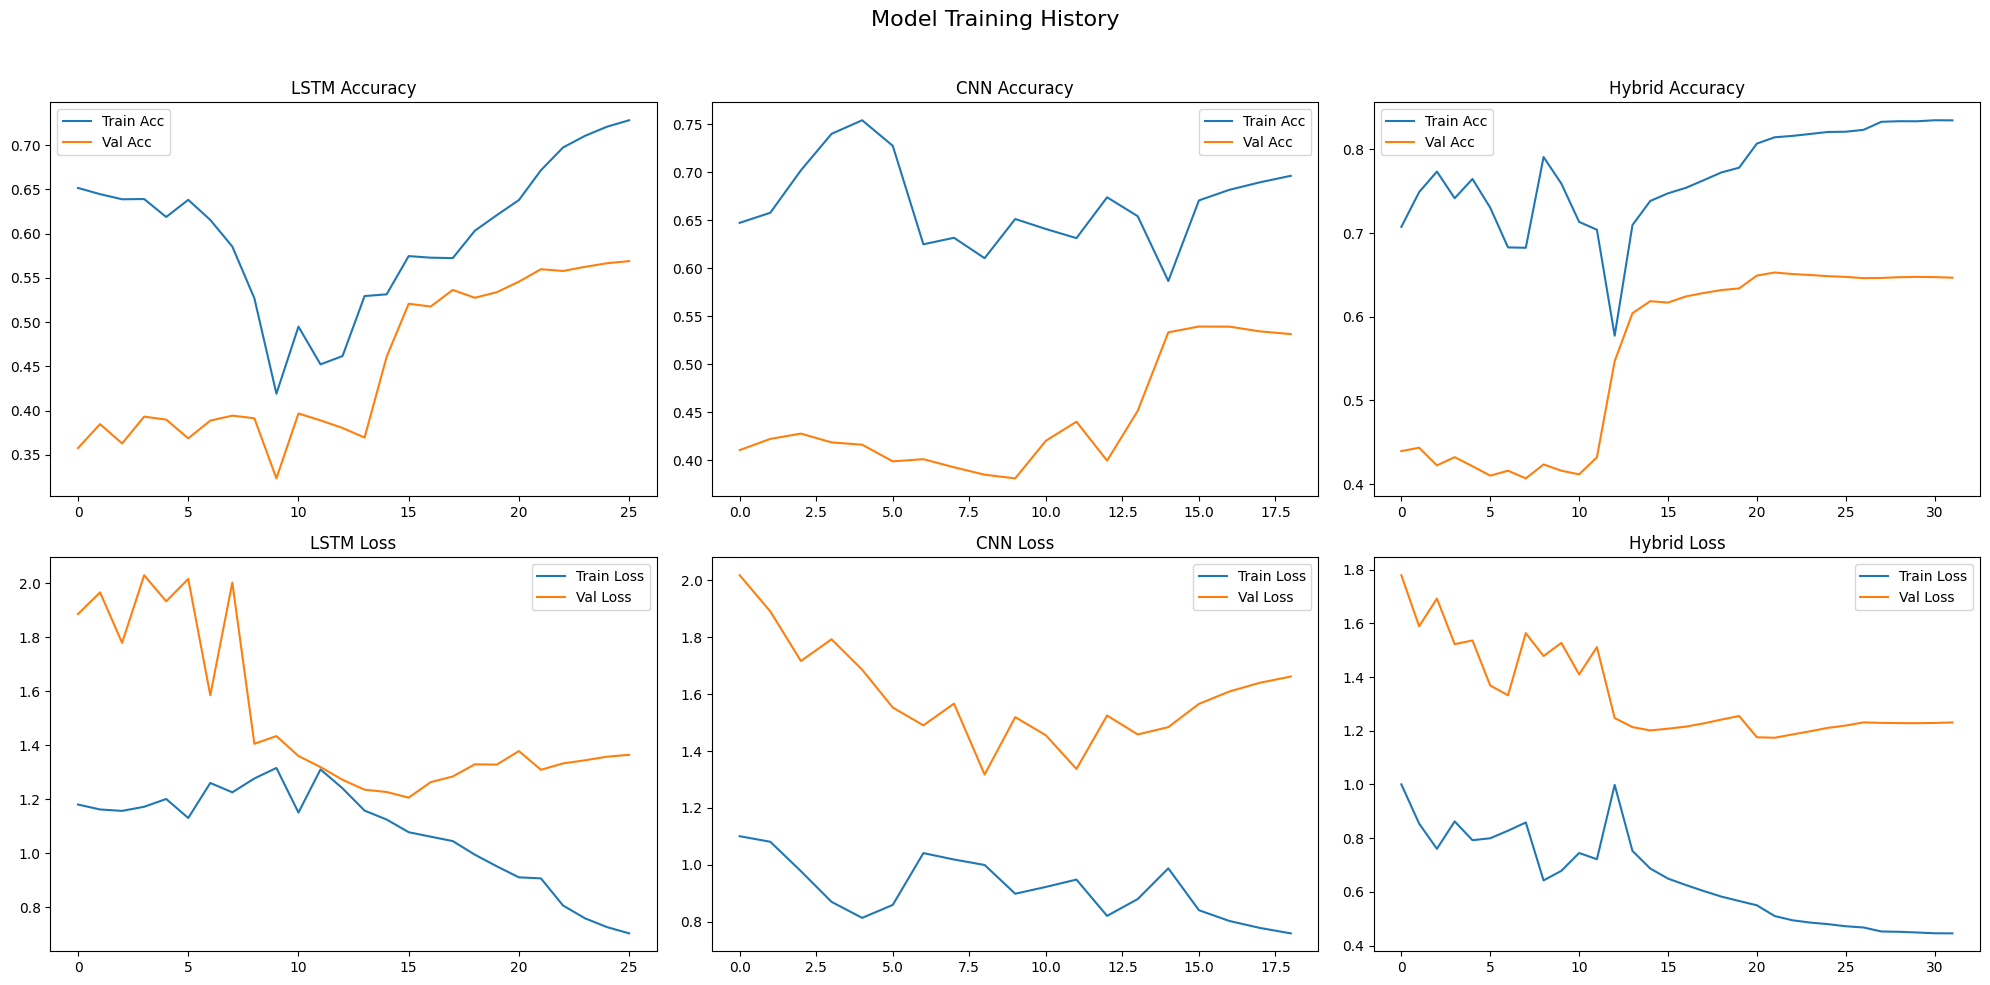

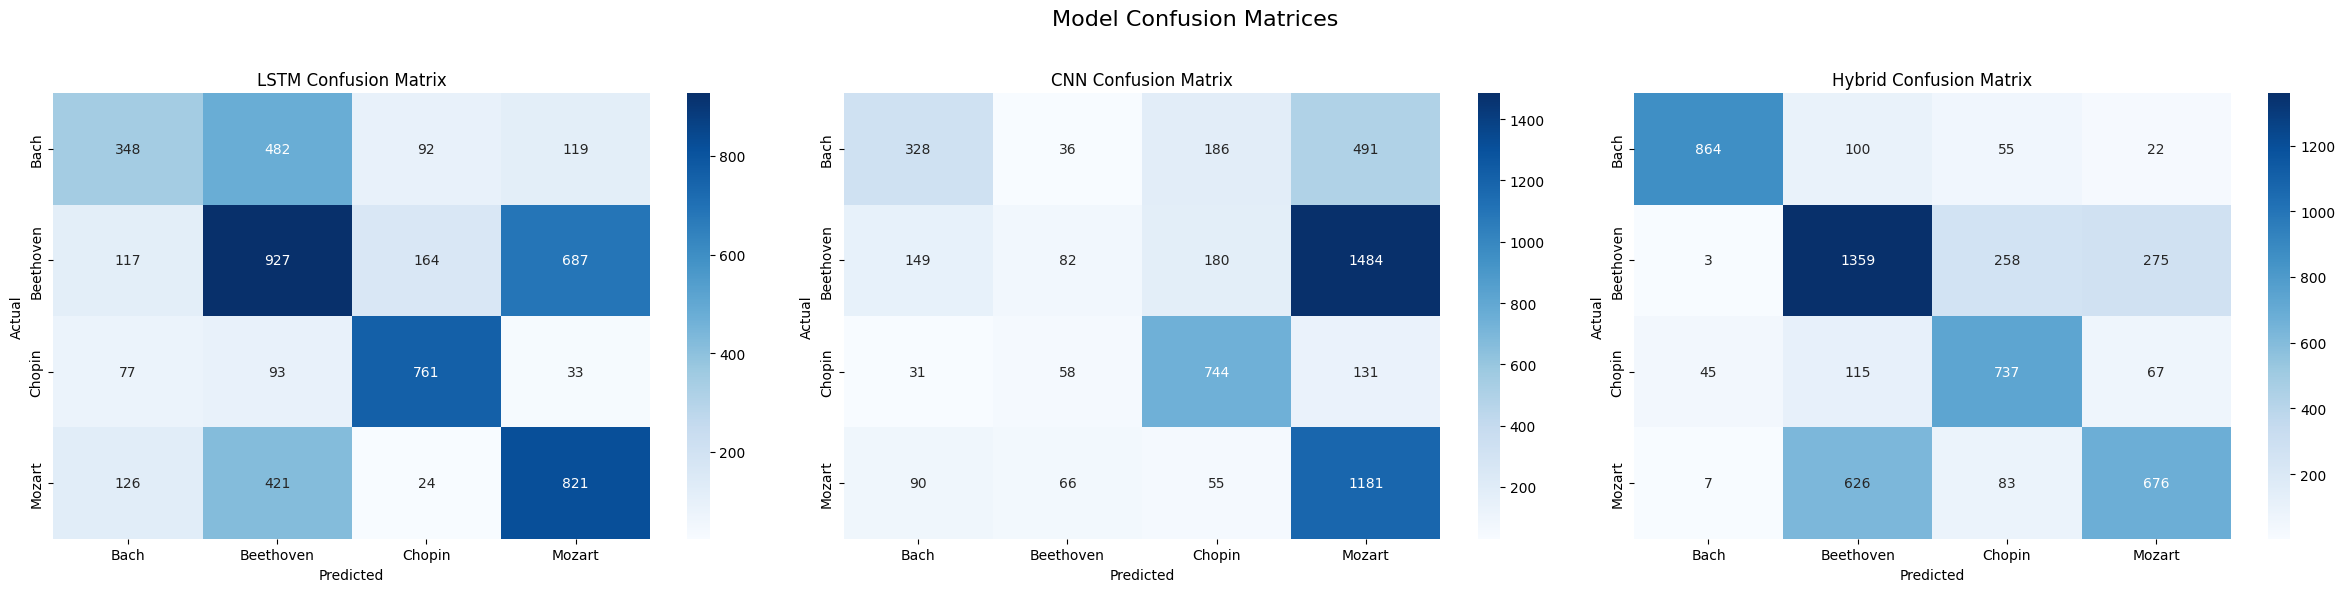

In [9]:
# 7. Visualize Results
# Training History
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Model Training History', fontsize=16)
for i, (name, info) in enumerate(models_info.items()):
    # Accuracy
    axes[0, i].plot(info['history'].history['accuracy'], label='Train Acc')
    axes[0, i].plot(info['history'].history['val_accuracy'], label='Val Acc')
    axes[0, i].set_title(f'{name} Accuracy')
    axes[0, i].legend()
    # Loss
    axes[1, i].plot(info['history'].history['loss'], label='Train Loss')
    axes[1, i].plot(info['history'].history['val_loss'], label='Val Loss')
    axes[1, i].set_title(f'{name} Loss')
    axes[1, i].legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}/training_history.png')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Model Confusion Matrices', fontsize=16)
for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=composers, yticklabels=composers, ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}/confusion_matrices.png')
plt.show()

In [10]:
# 8. Final Summary
print("\nFinal Model Comparison")
summary_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [res['accuracy'] for res in results.values()]
})
print(summary_df.sort_values(by='Accuracy', ascending=False))


Final Model Comparison
    Model  Accuracy
2  Hybrid  0.687075
0    LSTM  0.539872
1     CNN  0.441232


In [11]:
# 10. Model Optimization (Hyperparameter Tuning)
print("\n\n--- Starting Hyperparameter Tuning for Hybrid Model ---")

# If not already installed
!pip -q install keras-tuner
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Resolve shapes/metadata up front (avoid globals inside the builder)
seq_len = int(X_train_seq.shape[1])
num_classes = int(y_train.shape[1])
vocab = int(vocab_size)  # make sure vocab_size = len(note_to_int)

def build_tuned_hybrid_model(hp: kt.HyperParameters):
    # Tunables
    lstm_units   = hp.Int('lstm_units', min_value=128, max_value=512, step=128)
    cnn_filters  = hp.Int('cnn_filters', min_value=64,  max_value=256, step=64)
    dropout      = hp.Float('dropout', min_value=0.2,  max_value=0.5,  step=0.1)
    lr           = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    # Sequence input + embedding
    seq_in = Input(shape=(seq_len,), name='seq')
    # IMPORTANT: mask_zero=False because we route the embedding through CNN
    x = Embedding(input_dim=vocab, output_dim=128, input_length=seq_len, mask_zero=False, name='embedding')(seq_in)

    # CNN branch
    c = Conv1D(cnn_filters, kernel_size=5, activation='relu', padding='same', name='conv1')(x)
    c = MaxPooling1D(pool_size=2, name='pool1')(c)
    c = Dropout(dropout, name='drop_cnn')(c)
    c = Flatten(name='flat')(c)

    # LSTM branch
    l = LSTM(lstm_units, dropout=dropout, name='lstm')(x)

    # Tempo branch (aux numeric feature)
    tempo_in = Input(shape=(1,), name='tempo')
    t = Dense(16, activation='relu', name='tempo_dense1')(tempo_in)
    t = Dropout(dropout, name='drop_tempo')(t)

    # Combine
    h = Concatenate(name='concat')([l, c, t])
    h = Dense(256, activation='relu', name='dense1')(h)
    h = BatchNormalization(name='bn1')(h)
    h = Dropout(dropout, name='drop1')(h)
    out = Dense(num_classes, activation='softmax', name='out')(h)

    model = Model(inputs=[seq_in, tempo_in], outputs=out, name='hybrid_tuned')
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    hypermodel=build_tuned_hybrid_model,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='composer_tuning_random',
    overwrite=True,
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

tuner.search(
    x=[X_train_seq, X_train_tempo],
    y=y_train,
    validation_data=([X_val_seq, X_val_tempo], y_val),
    epochs=50,
    callbacks=[stop_early],
    class_weight=class_weight_dict,
    verbose=1,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best HPs:", best_hp.values)

# (Optional) Build and train best model
best_model = tuner.hypermodel.build(best_hp)
history = best_model.fit(
    [X_train_seq, X_train_tempo], y_train,
    validation_data=([X_val_seq, X_val_tempo], y_val),
    epochs=20,
    callbacks=[stop_early],
    class_weight=class_weight_dict,
    verbose=1,
)

Trial 5 Complete [00h 02m 34s]
val_accuracy: 0.6649753451347351

Best val_accuracy So Far: 0.6855531930923462
Total elapsed time: 00h 27m 59s
Best HPs: {'lstm_units': 384, 'cnn_filters': 256, 'dropout': 0.4, 'learning_rate': 0.0001}
Epoch 1/50
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.6071 - loss: 1.1011 - val_accuracy: 0.6226 - val_loss: 1.2329
Epoch 2/50
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9226 - loss: 0.2385 - val_accuracy: 0.6530 - val_loss: 1.6241
Epoch 3/50
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9811 - loss: 0.0643 - val_accuracy: 0.6431 - val_loss: 2.0557
Epoch 4/50
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9917 - loss: 0.0300 - val_accuracy: 0.6571 - val_loss: 2.0435
Epoch 5/50
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9942 - loss: 0.0208 - val_accuracy: 0.6395 - val_loss: 2.4812
Epoch 6/50
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9964 - loss: 0.0141 - val_accuracy: 0